In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import ipywidgets as widgets
import scipy as sp

In [2]:
%matplotlib widget
plt.close("all")

In [3]:
spettri_dir = "data/spettri/"

available_spectra = [i for i in os.listdir(spettri_dir) if i.endswith(".xy") and "reference" not in i]

print("Available spectra:")
for i, spectrum in enumerate(available_spectra):
    print(f"{i}: {spectrum}")

Available spectra:
0: campione_perc_1.xy
1: campione_6nm_1.xy
2: campione_20nm_1.xy
3: campione_9nm_1.xy
4: campione_au_pt_1.xy


In [4]:
def align_spectrum(wavelenghts, absorbances, l0=880, a0=0.1):

    mask = wavelenghts > l0

    #fit = np.polyfit(wavelenghts[mask], absorbances[mask], 1)
    #ref_point = np.polyval(fit, l0)

    #ref_point = np.average(absorbances[mask])
    #ref_point = absorbances[np.argmin(np.abs(wavelenghts - l0))]

    ref_point = np.median(absorbances[mask])

    shift = a0 - ref_point

    return wavelenghts, absorbances + shift


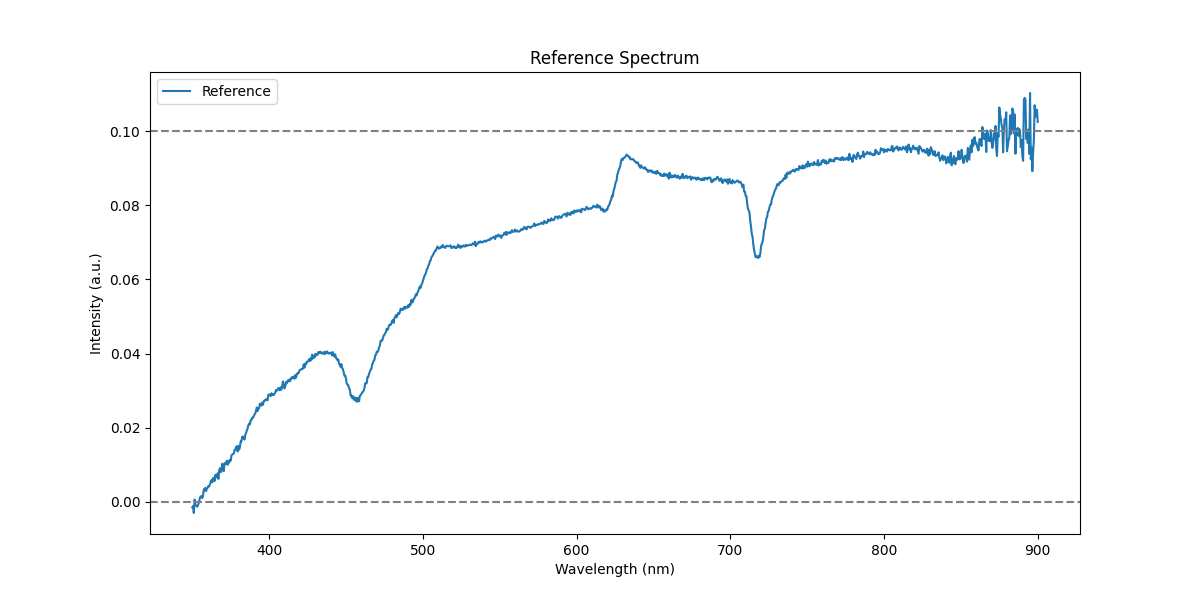

In [5]:
reference_spectrum = np.loadtxt(os.path.join(spettri_dir, "reference2.xy"))

reference_spectrum[:, 0], reference_spectrum[:, 1] = align_spectrum(reference_spectrum[:, 0], reference_spectrum[:, 1])

plt.figure(figsize=(12, 6))

plt.plot(reference_spectrum[:, 0], reference_spectrum[:, 1], label="Reference")
plt.axhline(0, color="gray", linestyle="--")
plt.axhline(0.1, color="gray", linestyle="--")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
plt.title("Reference Spectrum")
plt.legend()
plt.show()

In [6]:

def lorentz(x, x0, gamma, A, offset):
    return A * gamma**2 / ((x - x0)**2 + gamma**2) + offset

def fit_lorentzian(x, y, initial_guess):
    popt, pcov = sp.optimize.curve_fit(lorentz, x, y, p0=initial_guess)
    return popt, pcov   # parametri ottimali e matrice di covarianza


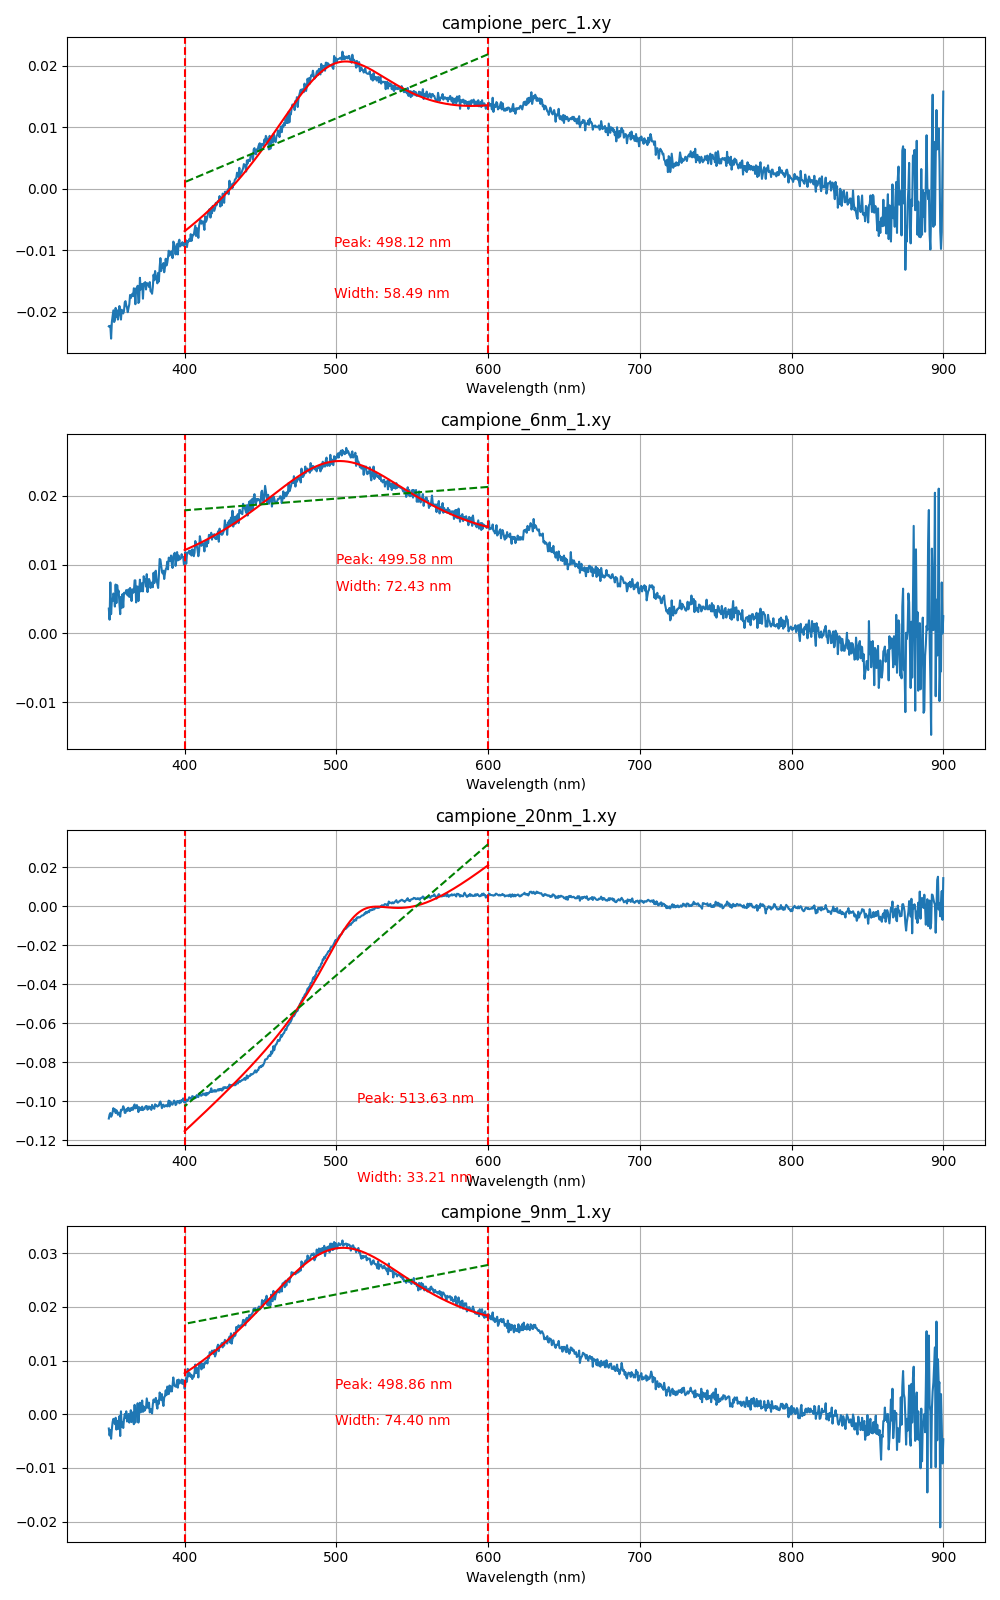

In [7]:
available_spectra = [i for i in available_spectra if "pt" not in i]
fig, axes = plt.subplots(len(available_spectra), 1, figsize=(10, 16))

peak_region = (400, 600)

params = {}

for ax, spectrum in zip(axes, available_spectra):

    data = np.loadtxt(os.path.join(spettri_dir, spectrum))

    data[:, 0], data[:, 1] = align_spectrum(data[:, 0], data[:, 1])

    data[:, 1] -= reference_spectrum[:, 1]

    ax.plot(data[:, 0], data[:, 1], label=spectrum)

    ax.axvline(peak_region[0], color="red", linestyle="--", label="Peak Region")
    ax.axvline(peak_region[1], color="red", linestyle="--")

    peak_region_mask = (data[:, 0] >= peak_region[0]) & (data[:, 0] <= peak_region[1])
    peak_region_data = data[peak_region_mask]
    baseline = np.polyfit(peak_region_data[:, 0], peak_region_data[:, 1], deg=1)
    baseline_values = np.polyval(baseline, peak_region_data[:, 0])

    peak_region_without_baseline = peak_region_data[:, 1] - baseline_values
    initial_guess = [peak_region_data[:, 0][np.argmax(peak_region_without_baseline)], 10, np.max(peak_region_without_baseline), 0]
    popt, pcov = fit_lorentzian(peak_region_data[:, 0], peak_region_without_baseline, initial_guess)

    params[spectrum] = {
        "peak_position": popt[0],
        "width": popt[1],
        "amplitude": popt[2],
        "baseline_offset": popt[3],
        "covariance": pcov
    }

    ax.plot(peak_region_data[:, 0], lorentz(peak_region_data[:, 0], *popt) + baseline_values, color="red", label="Lorentzian Fit")

    ax.text(popt[0], np.min(peak_region_data[:, 1]), f"Peak: {popt[0]:.2f} nm", color="red")
    ax.text(popt[0], np.min(peak_region_data[:, 1]) - np.std(peak_region_data[:, 1]), f"Width: {popt[1]:.2f} nm", color="red")

    ax.plot(peak_region_data[:, 0], baseline_values, color="green", linestyle="--", label="Baseline")

    ax.set_title(spectrum)
    ax.set_xlabel("Wavelength (nm)")
    ax.grid()
plt.tight_layout()
plt.show()

In [8]:
for key, val in params.items():

    amplitude_error = np.sqrt(val["covariance"][2, 2]) if val["covariance"].shape[0] > 2 else np.nan

    print(f"Spectrum: {key}")
    print(f"  Peak Position: {val['peak_position']:.4f} nm")
    print(f"  Width: {val['width']:.4f} nm")
    print(f"  Amplitude: {val['amplitude']:.4f} ± {amplitude_error:.4f}")
    print(f"  Baseline Offset: {val['baseline_offset']:.4f}")
    print()

Spectrum: campione_perc_1.xy
  Peak Position: 498.1192 nm
  Width: 58.4884 nm
  Amplitude: 0.0230 ± 0.0003
  Baseline Offset: -0.0140

Spectrum: campione_6nm_1.xy
  Peak Position: 499.5812 nm
  Width: 72.4315 nm
  Amplitude: 0.0171 ± 0.0004
  Baseline Offset: -0.0117

Spectrum: campione_20nm_1.xy
  Peak Position: 513.6335 nm
  Width: 33.2093 nm
  Amplitude: 0.0381 ± 0.0010
  Baseline Offset: -0.0157

Spectrum: campione_9nm_1.xy
  Peak Position: 498.8593 nm
  Width: 74.4004 nm
  Amplitude: 0.0278 ± 0.0005
  Baseline Offset: -0.0193



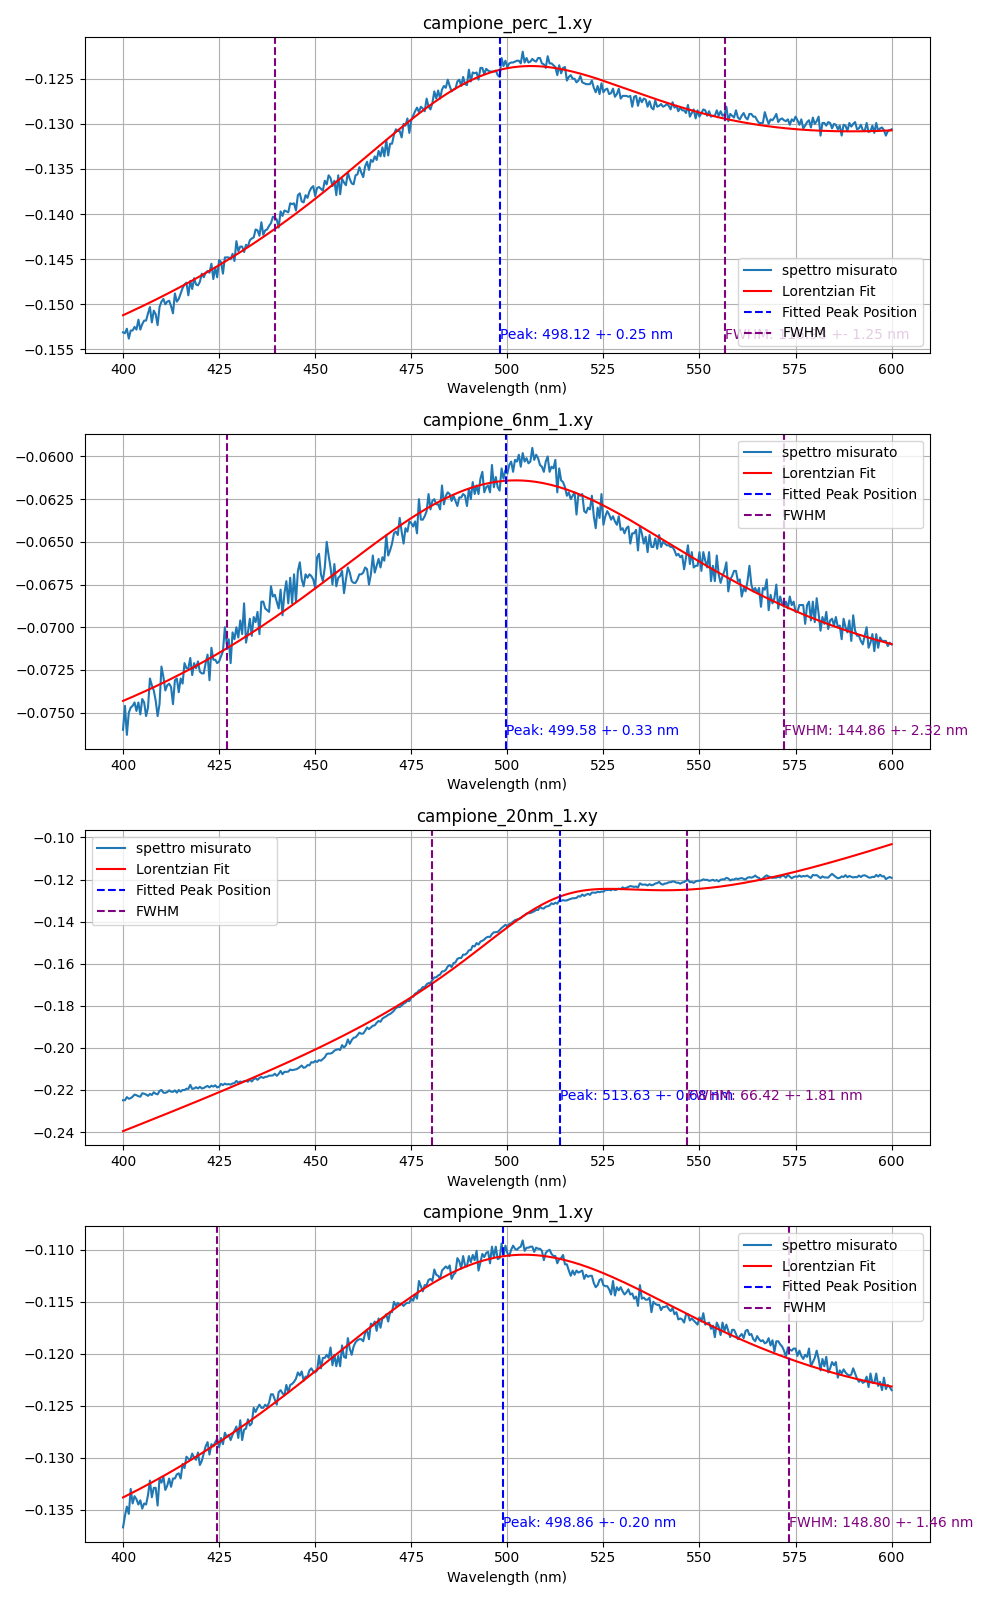

In [9]:
fig, axes = plt.subplots(len(available_spectra), 1, figsize=(10, 16))

for ax, spectrum, p in zip(axes, available_spectra, [params[s] for s in available_spectra]):

    data = np.loadtxt(os.path.join(spettri_dir, spectrum))
    data[:, 1] -= reference_spectrum[:, 1]

    peak_region_mask = (data[:, 0] >= peak_region[0]) & (data[:, 0] <= peak_region[1])
    peak_region_data = data[peak_region_mask]

    baseline = np.polyfit(peak_region_data[:, 0], peak_region_data[:, 1], deg=1)
    baseline_values = np.polyval(baseline, peak_region_data[:, 0])

    param_errors = np.sqrt(np.diag(p["covariance"]))

    ax.plot(peak_region_data[:, 0], peak_region_data[:, 1], label="spettro misurato")
    ax.plot(peak_region_data[:, 0], lorentz(peak_region_data[:, 0], p["peak_position"], p["width"], p["amplitude"], p["baseline_offset"]) + baseline_values, color="red", label="Lorentzian Fit")

    ax.axvline(p["peak_position"], color="blue", linestyle="--", label="Fitted Peak Position")
    ax.text(p["peak_position"], np.min(peak_region_data[:, 1]), f"Peak: {p['peak_position']:.2f} +- {param_errors[0]:.2f} nm", color="blue")

    # larghezza a mezza altezza (FWHM)
    fwhm = 2 * p["width"]
    ax.axvline(p["peak_position"] + fwhm/2, color="purple", linestyle="--", label="FWHM")
    ax.axvline(p["peak_position"] - fwhm/2, color="purple", linestyle="--")
    ax.text(p["peak_position"] + fwhm/2, np.min(peak_region_data[:, 1]), f"FWHM: {fwhm:.2f} +- {param_errors[1]:.2f} nm", color="purple")

    ax.set_title(spectrum)
    ax.set_xlabel("Wavelength (nm)")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()
    

In [10]:
print("spettri: ", available_spectra)

spettri:  ['campione_perc_1.xy', 'campione_6nm_1.xy', 'campione_20nm_1.xy', 'campione_9nm_1.xy']


In [11]:
ordered_spectra = ["campione_6nm_1.xy", "campione_9nm_1.xy", "campione_perc_1.xy"]#, "campione_20nm_1.xy"]

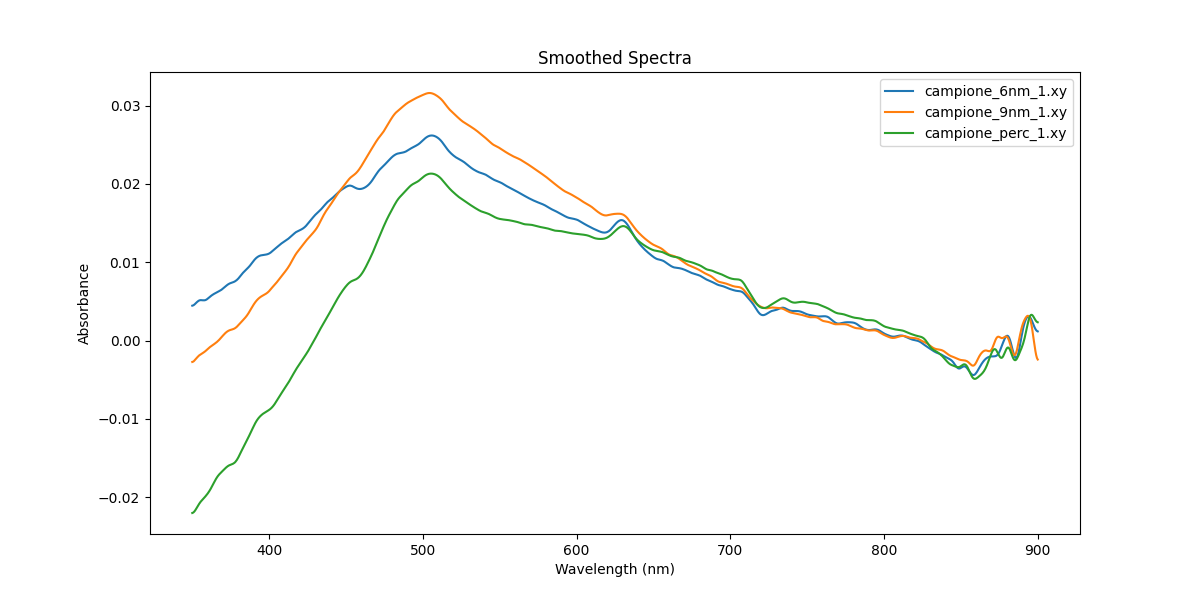

In [12]:
plt.figure(figsize=(12, 6))

for spectrum in ordered_spectra:
    data = np.loadtxt(os.path.join(spettri_dir, spectrum))
    data[:, 0], data[:, 1] = align_spectrum(data[:, 0], data[:, 1])

    data[:, 1] -= reference_spectrum[:, 1]
 
    smooth_spectrum = sp.ndimage.gaussian_filter1d(data[:, 1], sigma=5)

    plt.plot(data[:, 0], smooth_spectrum, label=spectrum)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.title("Smoothed Spectra")
plt.legend()
plt.show()

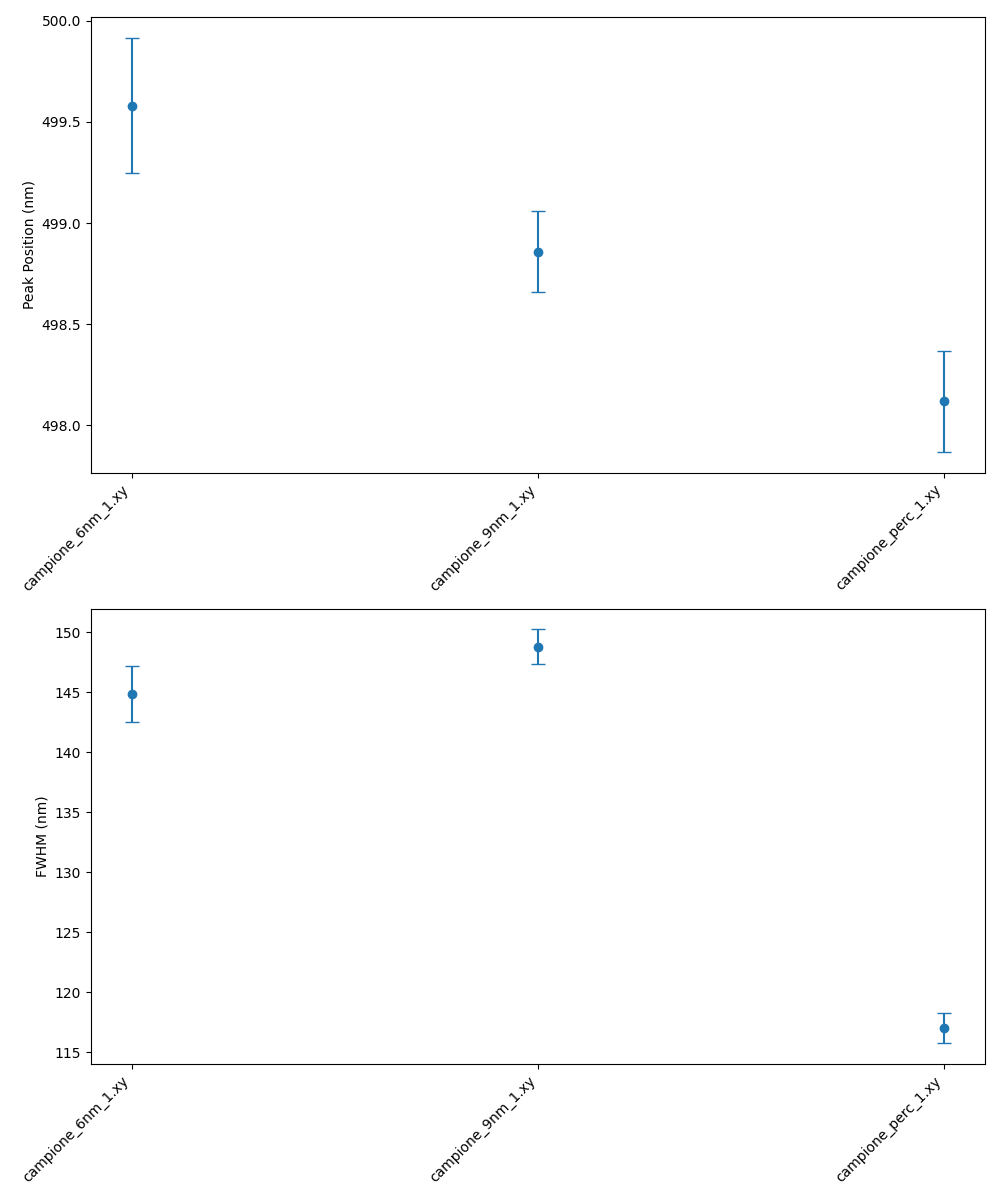

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

param_errors = {s: np.sqrt(np.diag(params[s]["covariance"])) for s in ordered_spectra}

# posizione picchi
ax = axes[0]
peak_positions = [params[s]["peak_position"] for s in ordered_spectra]
#ax.scatter(range(len(ordered_spectra)), peak_positions)
ax.errorbar(range(len(ordered_spectra)), peak_positions, yerr=[param_errors[s][0] for s in ordered_spectra], fmt='o', capsize=5)
ax.set_xticks(range(len(ordered_spectra)))
ax.set_xticklabels(ordered_spectra, rotation=45, ha="right")
ax.set_ylabel("Peak Position (nm)")

# larghezza picchi
ax = axes[1]
fwhm_values = [2 * params[s]["width"] for s in ordered_spectra]
ax.errorbar(range(len(ordered_spectra)), fwhm_values, yerr=[param_errors[s][1] for s in ordered_spectra], fmt='o', capsize=5)
ax.set_xticks(range(len(ordered_spectra)))
ax.set_xticklabels(ordered_spectra, rotation=45, ha="right")
ax.set_ylabel("FWHM (nm)")

plt.tight_layout()
plt.show()

In [14]:
def bruggemann(f, epsilon_m, epsilon_d):
    return 1/4 * (epsilon_d * (2 - 3*f) + epsilon_m * (3*f - 1) + np.sqrt((epsilon_d * (2 - 3*f) + epsilon_m * (3*f - 1))**2 + 8 * epsilon_d * epsilon_m))


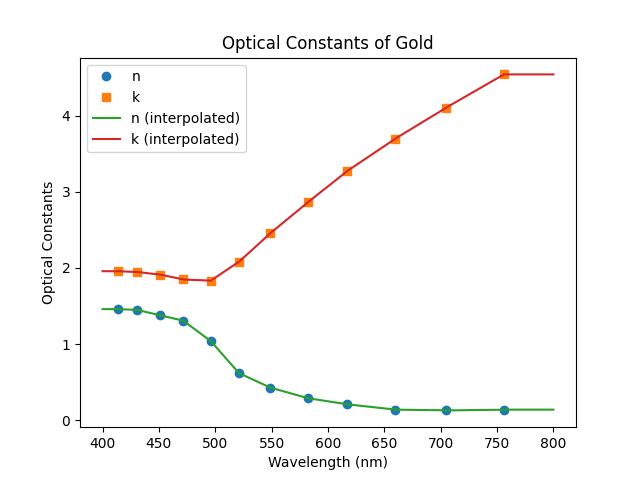

In [15]:
ns = np.loadtxt("temp/analisi/Au_n.txt")
ks = np.loadtxt("temp/analisi/Au_k.txt")
evs = np.loadtxt("temp/analisi/Au_evs.txt")
optical_consts_lambdas = (1240 / evs)

lambdas = np.linspace(400, 800, 1000)

order = np.argsort(optical_consts_lambdas)
xp = optical_consts_lambdas[order]
ns_sorted = ns[order]
ks_sorted = ks[order]

# poi applichi la maschera su xp (già ordinato)
mask = (xp >= np.min(lambdas)) & (xp <= np.max(lambdas))

ns_interp = np.interp(lambdas, xp[mask], ns_sorted[mask])
ks_interp = np.interp(lambdas, xp[mask], ks_sorted[mask])

plt.figure()
plt.plot(xp[mask], ns_sorted[mask], label="n", marker="o", linestyle="")
plt.plot(xp[mask], ks_sorted[mask], label="k", marker="s", linestyle="")
plt.plot(lambdas, ns_interp, label="n (interpolated)", linestyle="-")
plt.plot(lambdas, ks_interp, label="k (interpolated)", linestyle="-")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Optical Constants")
plt.title("Optical Constants of Gold")
plt.legend()
plt.show()


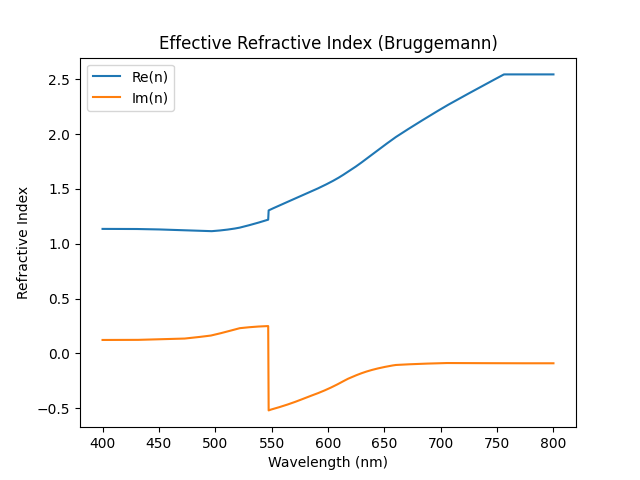

In [16]:
f = 0.1

epsilon_m = (ns_interp + 1j * ks_interp)**2
epsilon_d = 1

epsilon_eff = bruggemann(f, epsilon_m, epsilon_d)

n = np.sqrt(epsilon_eff)

plt.figure()

plt.plot(lambdas, n.real, label="Re(n)")
plt.plot(lambdas, n.imag, label="Im(n)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Refractive Index")
plt.title("Effective Refractive Index (Bruggemann)")
plt.legend()
plt.show()
